In [6]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit import Parameter
from qiskit.quantum_info import Pauli

import numpy as np
from scipy.optimize import minimize

import matplotlib.pyplot as plt

Single-qubit Hamiltonian VQE circuit:
   ┌───────┐
q: ┤ Ry(θ) ├
   └───────┘


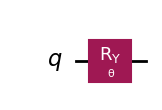

In [40]:
# Single-qubit Hamiltonian VQE

#Task:         Ground state of 𝐻=𝑍
#              Plot cost vs θ
#              Find minimum energy

#Hamiltonian:  H=Z

#Ansatz:       ∣ψ(θ)⟩=Ry(θ)∣0⟩

#Cost:         C(θ)=  ⟨ψ(θ)∣Z∣ψ(θ)⟩

#Creating a parameter for variational circuit 
theta=Parameter('θ')

#Creating a single qubit circuit
quantcircuit=QuantumCircuit(1)

#Adding a parametrised rotation about Y-axis
quantcircuit.ry(theta,0)


#Visualise the circuit
print('Single-qubit Hamiltonian VQE circuit:')
print(quantcircuit)
quantcircuit.draw('mpl')






In [24]:
#defining the hamiltonian
Z=Pauli('Z')

#defining cost function
def cost_function(angle):
    qc_angle=quantcircuit.assign_parameters({theta:angle})
    state_circuit=Statevector.from_instruction(qc_angle)
    cost=state_circuit.expectation_value(Z)
    return cost

#test values
test_angle=0.1
print(cost_function(test_angle))


0.9950041652780258


In [55]:
initial_angle=np.random.uniform(0,2*np.pi)
initial_cost=cost_function(initial_angle)

result=minimize(cost_function,initial_angle,method='BFGS')
print(result.message)

optimal_theta=result.x[0]
optimal_cost=result.fun

qc_final=quantcircuit.assign_parameters({theta:optimal_theta})
final_state=Statevector.from_instruction(qc_final)

expected_state=Statevector([0,1])

print('\n')
print(f'The minimum energy is : {optimal_cost:.3f}')
print(f'Angle corresponding to minimum energy : {optimal_theta:.3f}')
print(f'State coreeseponding to minimum energy is : {final_state}')
print(f'Fidelity with the expected state={abs(expected_state.inner(final_state))**2 :.2f}')


Optimization terminated successfully.


The minimum energy is : -1.000
Angle corresponding to minimum energy : 3.142
State coreeseponding to minimum energy is : Statevector([-3.48933116e-07+0.j,  1.00000000e+00+0.j],
            dims=(2,))
Fidelity with the expected state=1.00


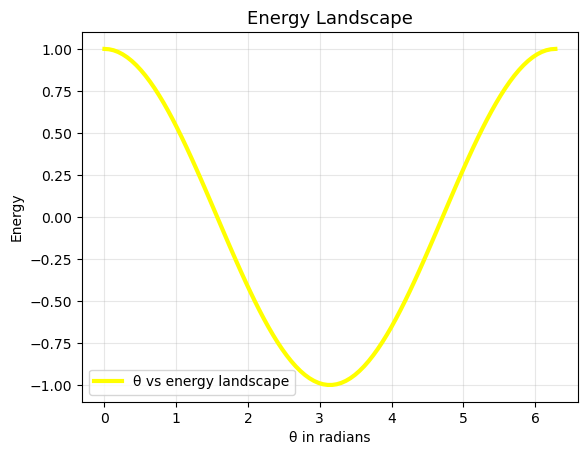

In [50]:
#Plotting the cost function which is the energy landscape
thetas=np.linspace(0,2*np.pi,100)
energy_cost=[cost_function(t) for t in thetas ]


plt.plot(thetas,energy_cost,color='yellow',linewidth=3,label='θ vs energy landscape')
plt.xlabel('θ in radians')
plt.ylabel('Energy')
plt.title('Energy Landscape',fontsize=13)
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()